In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.analysis.metrics import *
from src.modeling.feature_engineering import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from sklearn.model_selection import TimeSeriesSplit

##### **It is assumed that the time series are Non-stationary**

In [2]:
# Restaurant data with the ingredients to predict
daily_consumption_df = pd.read_csv('../../data/restaurant_daily_consumption.csv', index_col=0, parse_dates=True)
display(daily_consumption_df)

output_size = daily_consumption_df.columns.size
target_columns = daily_consumption_df.columns

,Salt,Sugar,Clove,Paprika
Date,,,,
2019-01-01,153.557043,1573.765650,0.097426,2.455129
2019-01-02,101.122931,1036.382257,0.064158,1.616792
2019-01-03,119.849399,1228.304898,0.076040,1.916198
2019-01-04,97.377637,997.997729,0.061782,1.556911
2019-01-05,202.245861,2072.764515,0.128317,3.233584
...,...,...,...,...
2019-06-26,116.104106,1189.920370,0.073663,1.856317
2019-06-27,205.991155,2111.149043,0.130693,3.293465
2019-06-28,179.774099,1842.457347,0.114059,2.874297


##### Apply Log Transformation

In [3]:
# Apply log transformation to numerical features
df_log_transformed = daily_consumption_df.copy()
df_log_transformed = np.log1p(daily_consumption_df) # Apply log1p (log(x + 1))
#display(df_log_transformed)

# Check correlation
corr_matrix = df_log_transformed.corr()
display(corr_matrix)

,Salt,Sugar,Clove,Paprika
Salt,1.000000,0.999997,0.961587,0.995016
Sugar,0.999997,1.000000,0.960940,0.994756
Clove,0.961587,0.960940,1.000000,0.983050
Paprika,0.995016,0.994756,0.983050,1.000000


##### Apply Rolling Cross-Validation

In [4]:
# Rolling Window CV with n folds
n_folds = 3  # You can increase this if needed
tss = TimeSeriesSplit(n_splits=n_folds)
print("Number of folds: ", n_folds)
print("Number of timespteps: ", len(df_log_transformed), "\n")


# For storing the results of each fold
fold_results = []
# For storing RMSE values
fold_rmse_values = []

print("Starting Time Series Cross-Validation... \n")
for fold_idx, (train_index, test_index) in enumerate(tss.split(df_log_transformed)):
    
    # Print the current fold and the training/testing time steps
    print(f"Fold {fold_idx+1}/{n_folds}")

    # Create training and test datasets for the current fold
    df_train = df_log_transformed.iloc[train_index]
    df_test = df_log_transformed.iloc[test_index]

    # Set the frequency explicitly to daily
    df_train = df_train.asfreq('D')
    df_test = df_test.asfreq('D')

    # Print the start and end timesteps for train and test sets
    print(f"Train set timesteps: {train_index[0]} to {train_index[-1]}")
    print(f"Test set timesteps: {test_index[0]} to {test_index[-1]}")

    print("Fitting the VAR model...")
    # Fit the VAR model
    var_model = VAR(df_train)
    # Fitting the model with the chosen lag order
    predicted_results = var_model.fit(maxlags=8, ic='aic')
    #print(predicted_results.summary())

    print("Start getting the forecasted results for the test set...")
    # Store predictions
    df_forecasts = pd.DataFrame(index=df_test.index, columns=df_test.columns)
    # Use rolling forecast (recursive forecasting)
    total_history = df_train.values.tolist()  # Initialize the history with the training data

    for t in range(len(df_test)):
        # Convert history to a NumPy array before forecasting
        history_array = np.array(total_history)
        # Predict one step ahead
        prediction = predicted_results.forecast(y=history_array, steps=1)
        # Store the prediction
        df_forecasts.iloc[t] = prediction[0]
        # Update history with the actual test value
        total_history.append(df_test.iloc[t].values)

    # Convert all columns to numeric values
    df_forecasts = df_forecasts.apply(pd.to_numeric, errors='coerce')

    # Reverse the log transformation
    test_actuals = np.expm1(df_test)
    test_forecasts = np.expm1(df_forecasts)

    # Calculate RMSE for this fold
    rmse = calculate_rmse(np.array(test_actuals), np.array(test_forecasts))
    fold_rmse_values.append(rmse)

    # Store the results of this fold
    fold_results.append({
        'fold': fold_idx + 1,
        'test_start_timestep': test_index[0],
        'test_end_timestep': test_index[-1],
        'rmse': rmse,
        'test_pred': test_forecasts,  # denormalized
        'test_actuals': test_actuals,    # denormalized
    })

    print(f"Training completed. RMSE: {rmse}\n")


# Calculate average RMSE across all folds
average_rmse = np.mean(fold_rmse_values)
print(f"Average RMSE across {n_folds} folds: {average_rmse}")


Number of folds:  2
Number of timespteps:  181 

Starting Time Series Cross-Validation... 

Fold 1/2
Train set timesteps: 0 to 60
Test set timesteps: 61 to 120
Fitting the VAR model...
Start getting the forecasted results for the test set...
Training completed. RMSE: 331.43415152362473

Fold 2/2
Train set timesteps: 0 to 120
Test set timesteps: 121 to 180
Fitting the VAR model...
Start getting the forecasted results for the test set...
Training completed. RMSE: 198.99007315355698

Average RMSE across 2 folds: 265.2121123385908


Best fold is Fold 2 with RMSE: 198.99007315355698
Salt RMSE:  70.6616258824279
Sugar RMSE:  724.1095074956846
Clove RMSE:  0.04768214330441147
Paprika RMSE:  1.1414770928109803


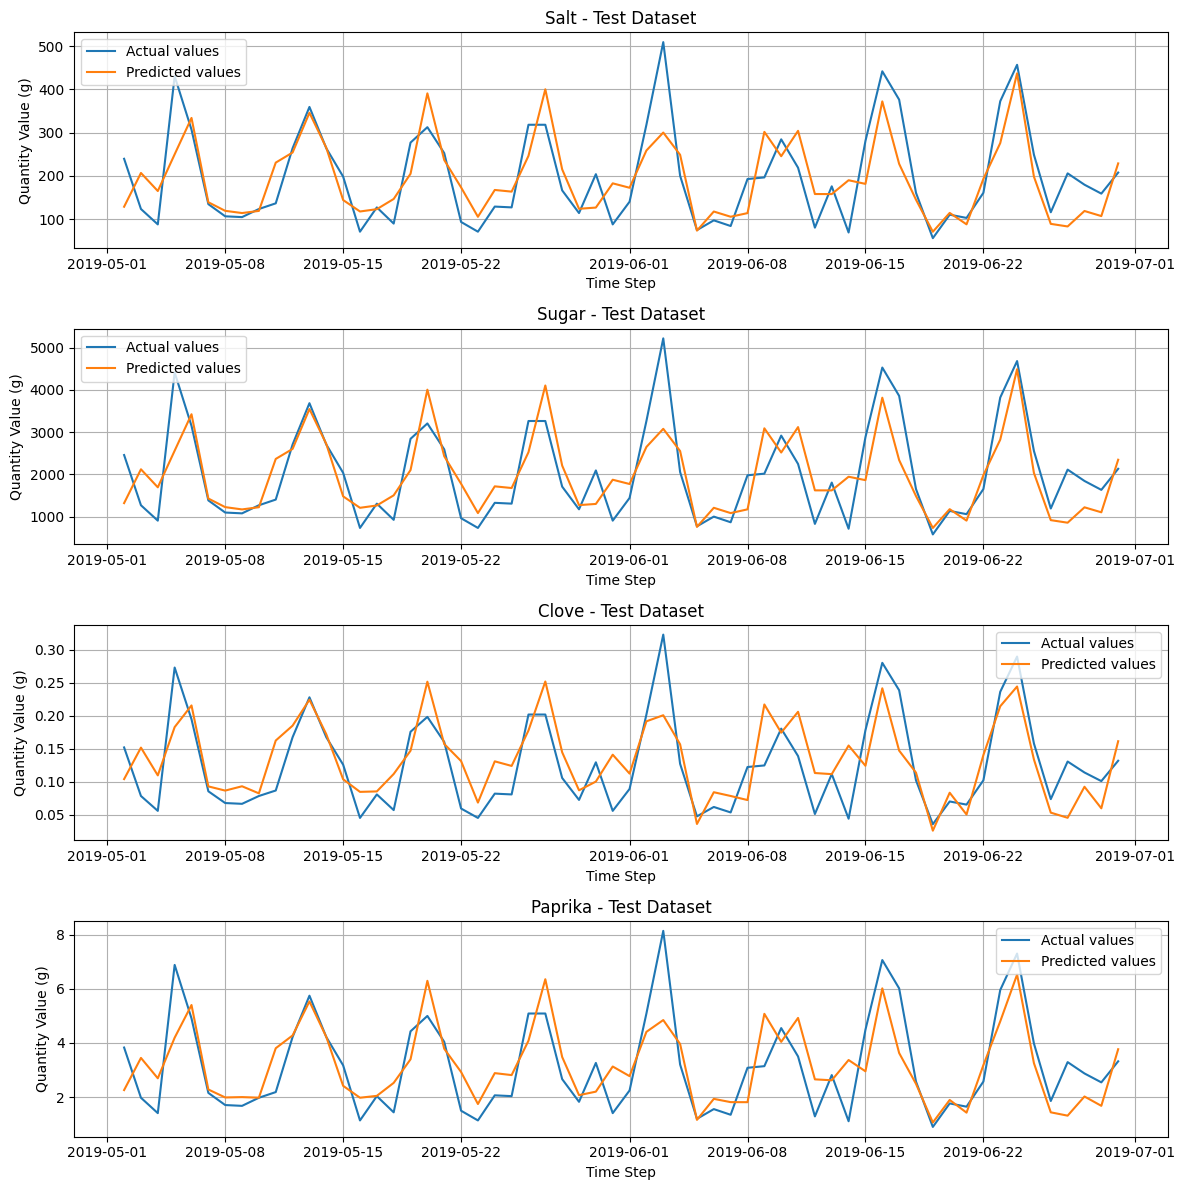

: 

In [5]:
# Find the fold with the best validation loss
best_fold_result = min(fold_results, key=lambda x: x['rmse'])
best_fold_idx = best_fold_result['fold'] - 1  # fold index starts from 0
# Print the fold with the best result
print(f"Best fold is Fold {best_fold_result['fold']} with RMSE: {best_fold_result['rmse']}")


# Start and end timesteps for the best fold
start_timestep = fold_results[best_fold_idx]['test_start_timestep']
end_timestep = fold_results[best_fold_idx]['test_end_timestep']

test_pred = fold_results[best_fold_idx]['test_pred']  # predictions from best fold
test_actuals = fold_results[best_fold_idx]['test_actuals']  # actual values from the best fold

# Prepare time steps for the test set of the best fold
time_steps_test = daily_consumption_df.index[start_timestep:end_timestep+1]

# Plotting the predicted vs actual values for each output
fig, axes = plt.subplots(output_size, 1, figsize=(12, 3 * output_size))
#fig.suptitle(f'Predicted vs Actual Values for Best Fold {best_fold_result["fold"]}', fontsize=16)

for idx, ingredient in enumerate(target_columns):
    ingr_rmse = calculate_rmse(test_actuals.iloc[:, idx], test_pred.iloc[:, idx])
    print(f'{ingredient} RMSE: ', ingr_rmse)

    # Testing data
    ingr_test_pred = test_pred.iloc[:, idx]
    ingr_test_actuals = test_actuals.iloc[:, idx]

    # Plot the results
    ax = axes[idx]
    ax.plot(time_steps_test, ingr_test_actuals, label='Actual values')
    ax.plot(time_steps_test, ingr_test_pred, label='Predicted values')
    ax.set_title(f'{ingredient} - Test Dataset')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Quantity Value (g)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()